Linear Regression R2: 0.8468053957655803
Random Forest R2: 0.9616981508899042
Linear Regression MAE: 1.2217615462334381
Random Forest MAE: 0.6223491803278687


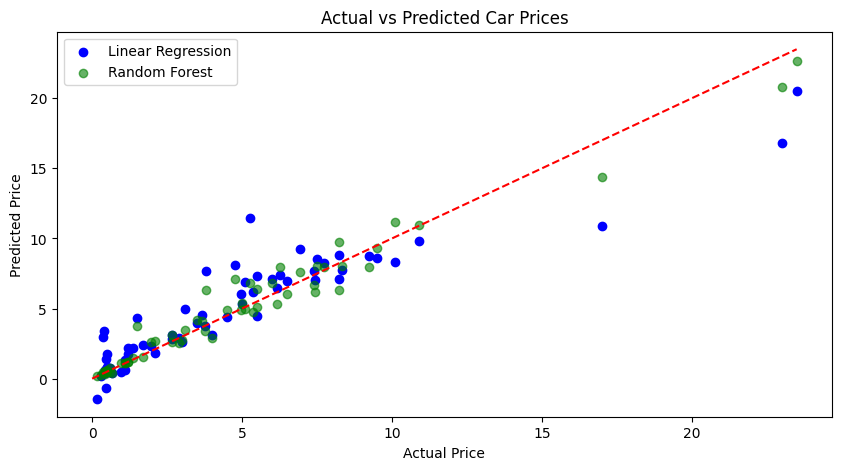

In [2]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# --- 2. Load Data ---
df = pd.read_csv("/content/car.csv")

# --- 3. Preprocessing ---
# Drop Car_Name (not useful for price prediction)
df = df.drop("Car_Name", axis=1)

# Encode categorical features
le = LabelEncoder()
for col in ["Fuel_Type", "Seller_Type", "Transmission"]:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# --- 4. Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. Train Models ---
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- 6. Evaluate ---
print("Linear Regression R2:", r2_score(y_test, y_pred_lin))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lin))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

# --- 7. Visualization ---
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lin, color="blue", label="Linear Regression")
plt.scatter(y_test, y_pred_rf, color="green", label="Random Forest", alpha=0.6)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.legend()
plt.show()
